## **PROJETO 1 - Análise de Vendas Para Loja de E-Commerce**



## 1. Definição do problema: 

Uma loja de e-commerce encontra-se em fase de crescimento e registra um volume cada vez maior de transações diárias. No entanto, esses dados de vendas, em seu estado bruto, ainda não são utilizados de forma eficiente para gerar informações estratégicas que apoiem a gestão do negócio.

Atualmente, muitas decisões são tomadas com base em intuição e observações parciais, o que limita a compreensão completa da performance da empresa. Essa falta de visibilidade dificulta a identificação dos produtos mais vendidos, dos canais de maior conversão e do perfil de consumo dos clientes.

**1.1 Objetivo:**  

Este projeto tem como objetivo transformar os dados brutos de vendas em insights acionáveis por meio de técnicas de análise de dados.

Especificamente, busca-se responder às seguintes questões de negócio:

- Identificar quais produtos possuem melhor desempenho de vendas;

- Determinar quais categorias geram maior faturamento;

- Analisar o comportamento das vendas ao longo do tempo, identificando tendências e sazonalidades;

- Mapear as regiões com maior volume de vendas e potencial de crescimento.

O propósito final é fornecer informações relevantes que apoiem a tomada de decisões estratégicas baseadas em dados.

**1.2 Proposta de Solução** 

A solução consiste em consolidar, limpar e analisar o histórico de dados de vendas da loja utilizando a linguagem Python e bibliotecas especializadas em análise de dados.

Após o tratamento e processamento das informações, será desenvolvido um relatório visual com o objetivo de apresentar os resultados de forma clara, objetiva e intuitiva. Esse relatório permitirá que as equipes de gestão, marketing e operações compreendam melhor a performance do negócio e utilizem os insights obtidos para orientar suas decisões.

**1.3 Resultados esperados:**

Ao final do projeto, espera-se alcançar os seguintes resultados:

* Identificação dos produtos mais e menos vendidos;

* Compreensão das categorias mais lucrativas;

* Visualização do comportamento das vendas ao longo do tempo;

* Identificação das regiões com maior potencial de mercado;

* Apoio à tomada de decisões estratégicas baseada em dados.

Com isso, a empresa poderá otimizar a gestão de estoque, melhorar a eficiência das campanhas de marketing, realizar um planejamento mais eficaz e fortalecer seu processo de expansão de forma sustentável.


## 2. Importação das bibliotecas:

Nesta etapa, são importadas as principais bibliotecas Python utilizadas para manipulação, análise e visualização dos dados, fornecendo ferramentas essenciais para trabalhar com dados de forma eficiente e gerar insights relevantes para o negócio.

As bibliotecas utilizadas foram:

* **pandas:** para manipulação e análise de dados em formato tabular;

* **numpy:** para operações numéricas e matemáticas;

* **matplotlib:** para criação de gráficos e visualizações;

* **seaborn:** para visualizações estatísticas mais elaboradas;

* **datetime:** para manipulação de datas;

* **random:** para geração de valores aleatórios.

In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import random
from datetime import datetime, timedelta 
%matplotlib inline 

**2.1 Atualização e Verificação das Versões:**

Nesta etapa, foi utilizada a biblioteca Watermark para registrar informações sobre o ambiente de desenvolvimento, como versões das bibliotecas e autoria do projeto, garantindo maior transparência e reprodutibilidade da análise.

In [139]:
!pip install -q -U watermark
%reload_ext watermark
%watermark -a "Data Science Academy , Aluna: Thais dos Santos Amorim" 
%watermark --iversions

Author: Data Science Academy , Aluna: Thais dos Santos Amorim

matplotlib: 3.10.0
numpy     : 2.3.2
pandas    : 2.3.2
seaborn   : 0.13.2



## 3. Carregamento de Dados Fictício

Nesta etapa, foi realizada a criação e o carregamento de um conjunto de dados fictício que simula as vendas de uma loja de e-commerce para mimetizar um cenário real de negócio.

Para isso, foi desenvolvida uma função em Python responsável por gerar registros contendo informações relevantes para a análise, como:

* Identificação do pedido
* Data da venda
* Produto e categoria
* Preço unitário e quantidade
* Cliente
* Cidade e estado

In [140]:
#Definindo a função para gerar dados fictícios de vendas

def dsa_dados_ficticios(num_registros = 600):

    """Gera um dataframe do pandas com dados fictícios de clientes."""

    # Mensagem para indicar o início da geração dos dados
    print(f"\nGerando {num_registros} registros de dados fictícios...\n")

    # Dicíonario com produtos, suas categorias e preços
    produtos = {
        'Laptop Gamer': {'categoria': 'Eletrônicos', 'preco': 7500.00},
        'Mouse Vertical': {'categoria': 'Acessórios', 'preco': 250.00},
        'Teclado Mecânico': {'categoria': 'Acessórios', 'preco': 550.00},
        'Monitor Ultrawide': {'categoria': 'Eletrônicos', 'preco': 2800.00},
        'Cadeira Gamer': {'categoria': 'Móveis', 'preco': 1200.00},
        'Headset 7.1': {'categoria': 'Acessórios', 'preco': 800.00},
        'Placa de Vídeo': {'categoria': 'Hardware', 'preco': 4500.00},
        'SSD 1TB': {'categoria': 'Hardware', 'preco': 600.00}
    }

    # Cria uma lista apenas com os nomes dos produtos para facilitar a seleção aleatória
    lista_produtos = list(produtos.keys())

    # Dicionário com cidades e seus respectivos estados
    cidades_estados = {'São Paulo': 'SP', 'Rio de Janeiro': 'RJ', 'Belo Horizonte': 'MG',
        'Porto Alegre': 'RS', 'Salvador': 'BA', 'Curitiba': 'PR', 'Fortaleza': 'CE'
    }

    # Cria uma lista apenas com os nomes das cidades para facilitar a seleção aleatória
    lista_cidades = list(cidades_estados.keys())

    #lista para amarzenar os registros de vendas
    dados_vendas = []

    # definição da data inicial dos pedidos
    data_inicial = datetime(2025, 1, 1)

    #loop para gerar os registros de vendas
    for i in range(num_registros):
        produto_nome = random.choice(lista_produtos) # Seleciona um produto aleatório da lista de produtos
        cidade_nome = random.choice(lista_cidades) # Seleciona uma cidade aleatória da lista de cidades
        quantidade = np.random.randint(1, 8) # Gera uma quantidade aleatória entre 1 e 8
        Data_Pedido = data_inicial + timedelta(days = random.randint(0, 90), hours = random.randint(0, 23)) # Gera uma data de pedido a partir da data inicial

        if produto_nome in ['Mouse Vertical', 'Teclado Mecânico']:
            preco_unitario = produtos[produto_nome]['preco'] * np.random.uniform(0.9, 1.0) #
        else:
            preco_unitario = produtos[produto_nome]['preco'] 

        # Adiciona o registro de venda à lista de dados de vendas
        dados_vendas.append({
            'ID_Pedido': 1000 + i,
            'Data_Pedido': Data_Pedido,
            'Nome_Produto': produto_nome,
            'Categoria': produtos[produto_nome]['categoria'],
            'Preco_Unitario': round(preco_unitario, 2),
            'Quantidade': quantidade,
            'ID_Cliente': np.random.randint(100, 150),
            'Cidade': cidade_nome,
            'Estado': cidades_estados[cidade_nome],
        })
    
    # Mensagem final indicando que a geração terminou
    print("Geração de dados concluída.\n")

    # Retorna os dados no formato de DataFrame
    return pd.DataFrame(dados_vendas)


## 4. Gerar, Carregar e Exporar os Dados

Nesta etapa, foi realizada a geração e o carregamento do conjunto de dados fictício utilizando a função desenvolvida anteriormente. O dataset foi armazenado na variável df_vendas, em formato DataFrame da biblioteca Pandas, permitindo sua manipulação e análise.

Após o carregamento, foi conduzida uma exploração inicial dos dados com o objetivo de compreender sua estrutura, organização e características principais. Foram visualizadas as primeiras e últimas linhas do DataFrame, possibilitando verificar o formato das informações e validar a geração correta dos registros.

Também foi utilizada a função info(), que permitiu analisar a quantidade de registros, os nomes das colunas, os tipos de dados e a presença de valores nulos. Em seguida, a função describe() forneceu um resumo estatístico das variáveis numéricas, incluindo medidas como média, valor mínimo, máximo e desvio padrão.

Além disso, foi verificada a dimensão do conjunto de dados por meio do atributo shape, identificando o número total de linhas e colunas, e o atributo dtypes, que confirmou os tipos de dados de cada variável.

In [ ]:
df_vendas  = dsa_dados_ficticios(500) # Gerando 500 registros de dados fictícios de vendas


Gerando 500 registros de dados fictícios...

Geração de dados concluída.



In [ ]:
type(df_vendas) #Verificando o tipo do objeto retornado pela função, que é um DataFrame do pandas.

pandas.core.frame.DataFrame

In [ ]:
df_vendas.shape #Verificando o número de linhas e colunas do DataFrame, que é de 500 linhas e 9 colunas.

(500, 9)

In [ ]:
df_vendas.head() #Exibindo as primeiras linhas do DataFrame para verificar a estrutura dos dados gerados.

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
0,1000,2025-02-24 08:00:00,Monitor Ultrawide,Eletrônicos,2800.0,1,132,Fortaleza,CE
1,1001,2025-01-20 00:00:00,Laptop Gamer,Eletrônicos,7500.0,3,129,Salvador,BA
2,1002,2025-03-05 14:00:00,Placa de Vídeo,Hardware,4500.0,1,148,Salvador,BA
3,1003,2025-03-13 07:00:00,Laptop Gamer,Eletrônicos,7500.0,4,126,Curitiba,PR
4,1004,2025-02-16 00:00:00,Laptop Gamer,Eletrônicos,7500.0,3,112,São Paulo,SP


In [ ]:
df_vendas.tail() #Exibindo as últimas linhas do DataFrame para verificar a estrutura dos dados gerados.

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
495,1495,2025-02-09 03:00:00,Monitor Ultrawide,Eletrônicos,2800.0,2,110,Porto Alegre,RS
496,1496,2025-03-11 13:00:00,Monitor Ultrawide,Eletrônicos,2800.0,7,115,Salvador,BA
497,1497,2025-02-25 00:00:00,Headset 7.1,Acessórios,800.0,1,100,Curitiba,PR
498,1498,2025-01-14 13:00:00,Placa de Vídeo,Hardware,4500.0,3,131,Fortaleza,CE
499,1499,2025-03-17 02:00:00,Monitor Ultrawide,Eletrônicos,2800.0,6,122,Rio de Janeiro,RJ


In [ ]:
df_vendas.info() #Exibindo informações sobre o DataFrame, como o número de entradas, tipos de dados e uso de memória.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       500 non-null    int64         
 1   Data_Pedido     500 non-null    datetime64[ns]
 2   Nome_Produto    500 non-null    object        
 3   Categoria       500 non-null    object        
 4   Preco_Unitario  500 non-null    float64       
 5   Quantidade      500 non-null    int64         
 6   ID_Cliente      500 non-null    int64         
 7   Cidade          500 non-null    object        
 8   Estado          500 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 35.3+ KB


In [ ]:
df_vendas.describe() #Exibindo estatísticas descritivas para as colunas numéricas do DataFrame, como contagem, média, desvio padrão, valores mínimos e máximos, e os quartis.

,ID_Pedido,Data_Pedido,Preco_Unitario,Quantidade,ID_Cliente
count,500.000000,500,500.000000,500.000000,500.000000
mean,1249.500000,2025-02-15 11:13:19.200000,2477.506020,3.934000,124.756000
min,1000.000000,2025-01-01 03:00:00,225.330000,1.000000,100.000000
25%,1124.750000,2025-01-24 04:45:00,600.000000,2.000000,113.000000
50%,1249.500000,2025-02-15 05:00:00,1200.000000,4.000000,124.000000
75%,1374.250000,2025-03-10 04:30:00,4500.000000,6.000000,137.000000
max,1499.000000,2025-04-01 18:00:00,7500.000000,7.000000,149.000000
std,144.481833,NaN,2530.417446,1.989361,14.167494


In [ ]:
df_vendas.dtypes #Exibindo os tipos de dados de cada coluna do DataFrame para verificar se estão adequados para análise.

ID_Pedido                  int64
Data_Pedido       datetime64[ns]
Nome_Produto              object
Categoria                 object
Preco_Unitario           float64
Quantidade                 int64
ID_Cliente                 int64
Cidade                    object
Estado                    object
dtype: object

## 5. Limpeza, Pré Processamento e Engenhara de Atributos

Nesta etapa, foi realizado o processo de limpeza, pré-processamento e engenharia de atributos, com o objetivo de preparar os dados para análise e garantir maior qualidade e consistência das informações.


Foi convertido a coluna 'Data_Pedido' para o tipo datetime para facilitar a análise temporal.

In [ ]:
df_vendas['Data_Pedido'] = pd.to_datetime(df_vendas['Data_Pedido']) 

* Criou-se a coluna 'Faturamento' multiplicando o preço unitário pela quantidade vendida
* Criou-se a coluna 'Status_Entrega' com base no estado de entrega, classificando como 'Rápida' para SP, RJ e MG, e 'Normal' para os demais estados.

In [ ]:
# Engenharia de Atributos
df_vendas ['Faturamento'] = df_vendas['Preco_Unitario'] * df_vendas['Quantidade']
df_vendas ['Status_Entrega'] = df_vendas['Estado'].apply(lambda estado: 'Rápida' if estado in [ 'SP', 'RJ', 'MG'] else 'Normal') 
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega
0,1000,2025-02-24 08:00:00,Monitor Ultrawide,Eletrônicos,2800.0,1,132,Fortaleza,CE,2800.0,Normal
1,1001,2025-01-20 00:00:00,Laptop Gamer,Eletrônicos,7500.0,3,129,Salvador,BA,22500.0,Normal
2,1002,2025-03-05 14:00:00,Placa de Vídeo,Hardware,4500.0,1,148,Salvador,BA,4500.0,Normal
3,1003,2025-03-13 07:00:00,Laptop Gamer,Eletrônicos,7500.0,4,126,Curitiba,PR,30000.0,Normal
4,1004,2025-02-16 00:00:00,Laptop Gamer,Eletrônicos,7500.0,3,112,São Paulo,SP,22500.0,Rápida


## 6. Análise Exploratória de dados (EDA)

Nesta etapa, foi realizada análises voltadas às questões estratégicas do projeto. Utilizando os dados tratados e as novas variáveis, foi identificado padrões e tendências essenciais para o suporte à decisão.

**6.1 Identificação dos produtos de maior sucesso:**

O objetivo principal desta etapa é identificar o volume de vendas por item, permitindo reconhecer a demanda e a relevância de cada produto no portfólio.

Para a extração dos resultados, os dados foram agrupados pelo campo Nome_Produto, aplicando-se a agregação de soma sobre a variável Quantidade. 

O código abaixo detalha o processamento e a ordenação decrescente para destacar os 10 itens com maior saída:

In [151]:
#tabela
top_produtos= df_vendas.groupby('Nome_Produto')['Quantidade'].sum().sort_values(ascending = False).head(10)
top_produtos


Nome_Produto
SSD 1TB              296
Laptop Gamer         277
Teclado Mecânico     265
Headset 7.1          249
Placa de Vídeo       230
Monitor Ultrawide    226
Cadeira Gamer        225
Mouse Vertical       199
Name: Quantidade, dtype: int64

Para facilitar a comparação entre as categorias, foi gerado um gráfico de barras horizontais. Esta escolha técnica permite uma leitura imediata da hierarquia de vendas, facilitando a identificação dos itens líderes de demanda e a disparidade entre os volumes de saída.

Eixo X (Horizontal): Representa a quantidade total de unidades vendidas.

Eixo Y (Vertical): Representa a relação dos nomes dos produtos, organizados de forma decrescente para priorizar os itens de maior sucesso no topo.

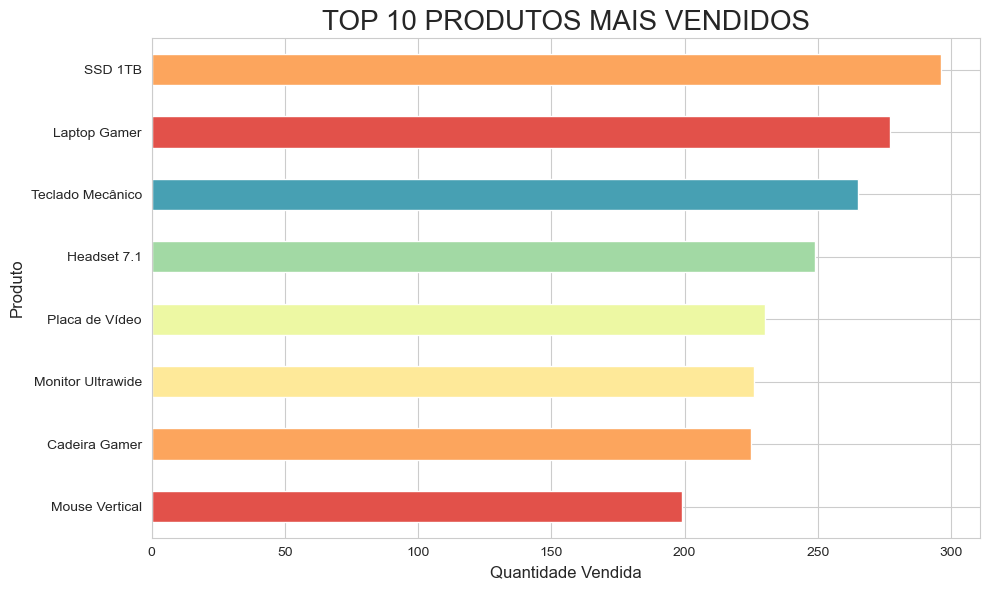

In [204]:
#gráfico
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))
top_produtos.sort_values(ascending = True).plot(kind = 'barh', color = sns.color_palette("Spectral"))
plt.title('Top 10 Produtos Mais Vendidos'.upper(), fontsize = 20)
plt.xlabel('Quantidade Vendida', fontsize = 12)
plt.ylabel('Produto', fontsize = 12)
plt.tight_layout()
plt.show()

A distribuição visual permite avaliar o grau de concentração das vendas, identificando se o volume está centralizado em itens específicos ou distribuído de forma equilibrada no portfólio. Os produtos posicionados no topo do gráfico demandam monitoramento prioritário para evitar rupturas de estoque, enquanto a base do ranking auxilia na identificação de itens com baixa rotatividade que podem exigir ações promocionais ou revisão de estoque.

**6.2 Identificação da perfomance de vendas MENSAL:**

Esta etapa foca na análise da evolução temporal do faturamento, permitindo identificar a sazonalidade e o ritmo de crescimento das vendas ao longo dos meses.

Para viabilizar essa visão, o campo Data_Pedido foi convertido para o formato de período mensal ('M')

In [213]:
df_vendas['Mês'] = df_vendas['Data_Pedido'].dt.to_period('M')
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega,Mês
0,1000,2025-02-24 08:00:00,Monitor Ultrawide,Eletrônicos,2800.0,1,132,Fortaleza,CE,2800.0,Normal,2025-02
1,1001,2025-01-20 00:00:00,Laptop Gamer,Eletrônicos,7500.0,3,129,Salvador,BA,22500.0,Normal,2025-01
2,1002,2025-03-05 14:00:00,Placa de Vídeo,Hardware,4500.0,1,148,Salvador,BA,4500.0,Normal,2025-03
3,1003,2025-03-13 07:00:00,Laptop Gamer,Eletrônicos,7500.0,4,126,Curitiba,PR,30000.0,Normal,2025-03
4,1004,2025-02-16 00:00:00,Laptop Gamer,Eletrônicos,7500.0,3,112,São Paulo,SP,22500.0,Rápida,2025-02


Em seguida, os dados foram agrupados para consolidar a soma da variável Faturamento por mês.

In [212]:
faturamento_mensal= df_vendas.groupby('Mês')['Faturamento'].sum()
faturamento_mensal.index = faturamento_mensal.index.strftime('%Y-%m')
faturamento_mensal.map('R$ {:,.2f}'.format) #map pandas!
faturamento_mensal

Mês
2025-01    1510512.91
2025-02    1397936.70
2025-03    1563340.77
2025-04     106500.00
Name: Faturamento, dtype: float64

Para facilitar a leitura dos resultados financeiros, foi gerado um gráfico de linhas. Esta escolha técnica permite observar flutuações, picos de venda e possíveis quedas de desempenho de forma contínua.

Eixo Y (Vertical): Representa o faturamento total, formatado em milhares (K) para simplificar a escala visual.

Eixo X (Horizontal): Representa a linha do tempo mensal.

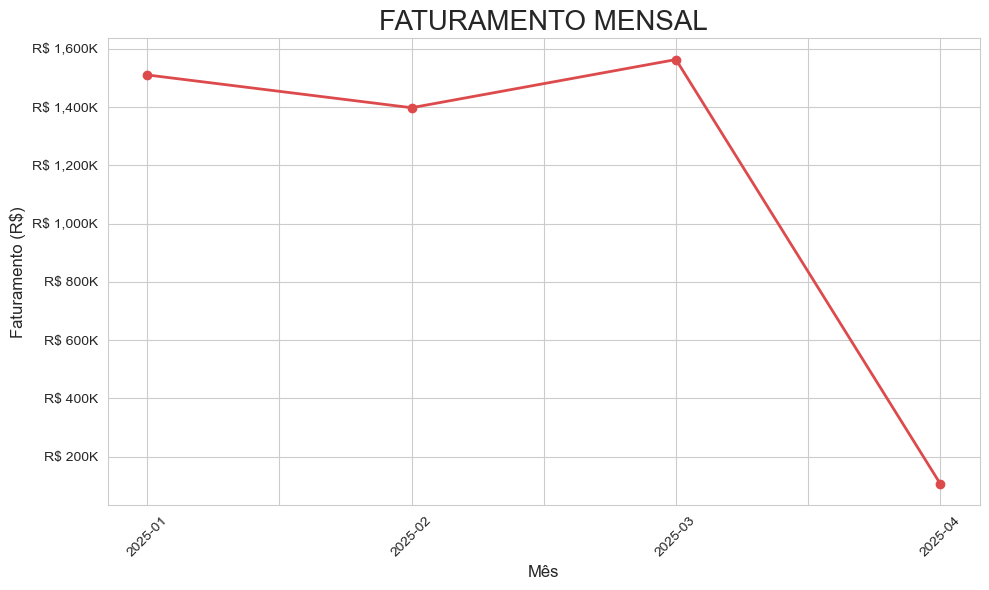

In [209]:
#gráfico
fig, ax = plt.subplots(figsize=(10, 6))

# Define a função de formatação personalizada para o eixo y
def formatador_milhares (y,pos):

    """Formata os valores do eixo y para mostrar em milhares (K) com cifrão R$."""

    return f'R$ {y/1000:,.0f}K'

formatter = FuncFormatter(formatador_milhares)
ax.yaxis.set_major_formatter(formatter)
faturamento_mensal.plot(ax = ax, kind = 'line', marker = 'o', linestyle='-', linewidth=2, markersize=6, color = sns.color_palette("Spectral", 7)[0])
ax.set_title('Faturamento Mensal'.upper(), fontsize = 20)
ax.set_ylabel('Faturamento (R$)', fontsize = 12)
plt.xticks(rotation = 45)
ax.set_xlabel('Mês', fontsize = 12)
plt.tight_layout()
plt.show()

A plotagem revela a dinâmica financeira do período analisado. Através deste gráfico, a gestão pode identificar se as metas mensais foram atingidas e correlacionar picos de faturamento com campanhas de marketing ou eventos sazonais. Como os dados são dinâmicos, a curva apresentada reflete o comportamento da amostra atual processada pelo sistema.

**6.3 Análise das Categorias mais lucrativas**:

Nesta etapa, o foco é identificar quais segmentos de mercado geram maior volume financeiro para a operação. Diferente da análise por produto individual, o agrupamento por categoria oferece uma visão macro, essencial para decisões de expansão de portfólio e alocação de investimentos.

In [164]:
df_vendas.head()


,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega,Mês
0,1000,2025-02-24 08:00:00,Monitor Ultrawide,Eletrônicos,2800.0,1,132,Fortaleza,CE,2800.0,Normal,2025-02
1,1001,2025-01-20 00:00:00,Laptop Gamer,Eletrônicos,7500.0,3,129,Salvador,BA,22500.0,Normal,2025-01
2,1002,2025-03-05 14:00:00,Placa de Vídeo,Hardware,4500.0,1,148,Salvador,BA,4500.0,Normal,2025-03
3,1003,2025-03-13 07:00:00,Laptop Gamer,Eletrônicos,7500.0,4,126,Curitiba,PR,30000.0,Normal,2025-03
4,1004,2025-02-16 00:00:00,Laptop Gamer,Eletrônicos,7500.0,3,112,São Paulo,SP,22500.0,Rápida,2025-02


O processamento consiste em agrupar os dados pela coluna Categoria e aplicar a soma sobre a variável Faturamento. Os resultados são ordenados de forma decrescente para destacar as categorias líderes em receita.

In [178]:
#tabela
top_categorias = df_vendas.groupby('Categoria')['Faturamento'].sum().sort_values(ascending=False)
top_categorias.map('R$ {:,.2f}'.format) #map pandas!
top_categorias

Categoria
Eletrônicos    2710300.00
Hardware       1212600.00
Acessórios      385390.38
Móveis          270000.00
Name: Faturamento, dtype: float64

Para esta análise, utilizamos um gráfico de barras. A aplicação da função formatador_milhares no eixo vertical (Eixo Y) permite uma leitura rápida e limpa dos valores em escala de milhares (K), facilitando a comparação entre os grupos.

A visualização também permite distinguir rapidamente categorias de alta performance daquelas que possuem menor participação no faturamento total, auxiliando na identificação de nichos que podem estar saturados ou áreas com potencial de crescimento.

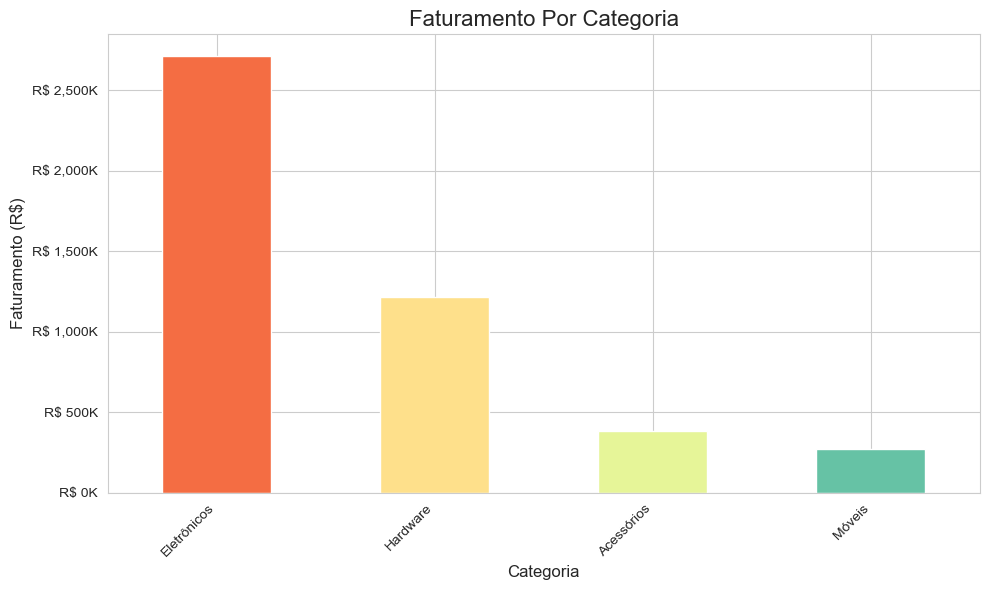

In [210]:
#gráfico

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

# Define a função de formatação personalizada para o eixo y
def formatador_milhares (y,pos):

    """Formata os valores do eixo y para mostrar em milhares (K) com cifrão R$."""

    return f'R$ {y/1000:,.0f}K'

formatter = FuncFormatter(formatador_milhares)
ax.yaxis.set_major_formatter(formatter)

faturamento_ordenado = top_categorias.sort_values(ascending = False)
# Plota os dados usando o objeto 'ax'
faturamento_ordenado.plot(kind = 'bar', ax = ax, color = sns.color_palette("Spectral", len(faturamento_ordenado)))

# Adiciona títulos e labels usando 'ax.set_...'
ax.set_title('Faturamento Por Categoria', fontsize = 16)
ax.set_xlabel('Categoria', fontsize = 12)
ax.set_ylabel('Faturamento (R$)', fontsize = 12)
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

A estrutura desta análise garante que, independentemente da variação dos dados, os gestores tenham uma visão consolidada de onde provém a maior rentabilidade do negócio no momento do processamento.

**6.4 Mapeamento Regional de Performance de Vendas**

Esta análise final tem como objetivo identificar a capacidade de expansão do negócio e localizar os mercados com maior concentração de faturamento.

O processamento envolve o agrupamento dos dados pela variável Estado, consolidando a soma do Faturamento e ordenando os resultados para evidenciar os polos comerciais mais fortes da operação.

In [179]:
#Tabela
vendas_estado = df_vendas.groupby('Estado')['Faturamento'].sum().sort_values(ascending=False)
vendas_estado.map('R$ {:,.2f}'.format) #map pandas!
vendas_estado

Estado
BA    826499.64
MG    818651.23
SP    710954.39
RJ    652785.59
CE    624344.27
PR    555204.84
RS    389850.42
Name: Faturamento, dtype: float64

Utilizamos um gráfico de barras verticais para comparar o desempenho financeiro entre os estados. A paleta de cores aplicada auxilia na distinção visual entre as regiões de alta e baixa performance.

Eixo X (Horizontal): Representa as Unidades Federativas (Estados).

Eixo Y (Vertical): Indica o faturamento total em Reais (R$).

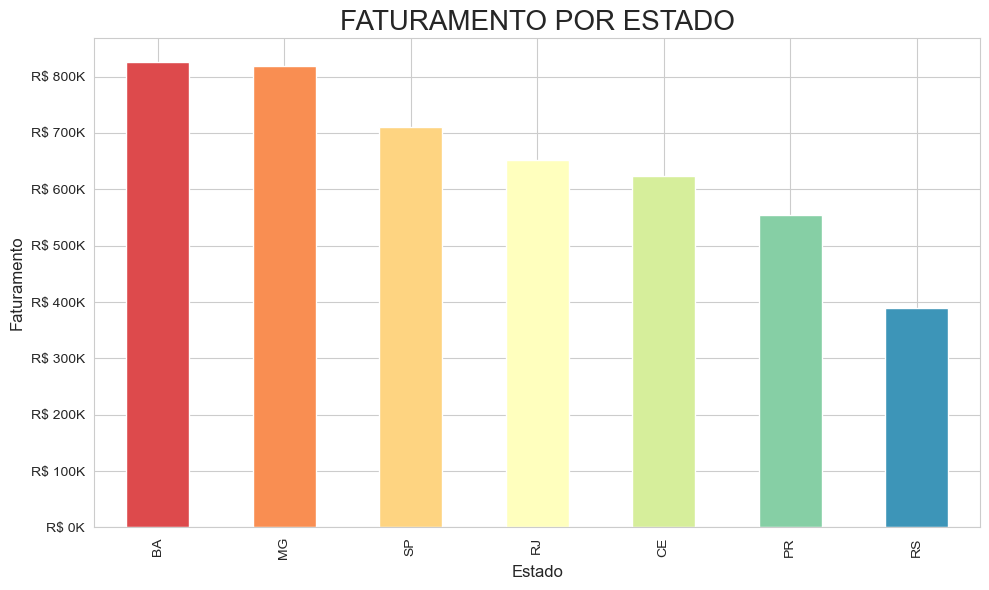

In [ ]:
# gráfico
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

# Define a função de formatação personalizada para o eixo y
def formatador_milhares(y, pos):
    """Formata os valores do eixo y para mostrar em milhares (K) com cifrão R$."""
    return f'R$ {y/1000:,.0f}K'

formatter = FuncFormatter(formatador_milhares)
ax.yaxis.set_major_formatter(formatter)

vendas_estado.sort_values(ascending=False).plot(kind='bar', color=sns.color_palette("Spectral", 7), ax=ax)
ax.set_title('FATURAMENTO POR ESTADO', fontsize=20)
ax.set_xlabel('Estado', fontsize=12)
ax.set_ylabel('Faturamento', fontsize=12)
plt.tight_layout()
plt.show()

A distribuição permite visualizar claramente quais estados atuam como os principais motores de receita do projeto. No contexto de dados dinâmicos, esta seção atua como um termômetro em tempo real, permitindo que a gestão identifique instantaneamente se a liderança de vendas permanece em polos tradicionais ou se novos mercados estão ganhando relevância.

## 7. Conclusão

O objetivo deste projeto foi demonstrar a conversão de dados de vendas em ativos estratégicos por meio de Python e suas bibliotecas fundamentais.

A aplicação de Análise Exploratória de Dados (EDA), Engenharia de Atributos e Visualização de Dados permitiu extrair inteligência de um conjunto de dados brutos.

Embora fundamentado em dados fictícios, o projeto simula com precisão um ambiente real de e-commerce, aplicando métricas de performance (KPIs) essenciais para o mercado.

## 8. Considerações Finais

Este trabalho reitera a análise de dados como pilar indispensável para a tomada de decisão baseada em evidências. A fluidez do processo demonstra a versatilidade do ecossistema Python (Pandas, NumPy e Matplotlib).

A estrutura desenvolvida é escalável e adaptável a dados reais, oferecendo uma base sólida para profissionais que buscam otimizar o desempenho operacional e estratégico de negócios. 

As competências consolidadas neste projeto incluem:

* Manipulação e Higienização de Dados;

* Feature Engineering (Engenharia de Atributos);

* Análise Estatística e Exploratória;

* Data Storytelling e Visualização Gráfica;

* Interpretação de Resultados Estratégicos.